# FFSL HRWUI Deep Learning Validation
**Author:** Magnus Tveit  
**Project:** Utah HRWUI Building Footprint Extraction  

Compares DL inference output against manually verified structures.  
Produces precision, recall, F1, confidence distribution analysis, and poster figures.

**Method:** A detection is counted as a True Positive if the DL polygon spatially overlaps  
with a verified structure polygon. All operations in EPSG:5070 (meters).  
Inference was run across the full study area including the 400m buffer,  
but validation is performed within the SES 7/8 boundary only.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Directories ───────────────────────────────────────────────────────────────
BASE        = '/uufs/chpc.utah.edu/common/home/u0972368/FFSL_HRWUI'
DL_SHP      = f'{BASE}/data/predictions_Weber_Clip/predictions_Weber_Clip.shp'
JOHNSON_SHP = f'{BASE}/data/inputs/Johnson_Weber/Johnson_Weber.shp'
OUT_DIR     = f'{BASE}/data/outputs'

# ── Shared style constants ────────────────────────────────────────────────────
FONT        = 'Liberation Sans'
POSTER_BLUE = '#1D5FA6'
col_tp      = '#2d7d46'
col_fp      = '#b7640d'
col_fn      = '#9E4F7E'

### Statistics for Poster

In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
dl      = gpd.read_file(DL_SHP)
johnson = gpd.read_file(JOHNSON_SHP)

# ── Reproject to EPSG:5070 ────────────────────────────────────────────────────
dl      = dl.to_crs(epsg=5070)
johnson = johnson.to_crs(epsg=5070)

# ── TP and FP: tag each DL detection ─────────────────────────────────────────
joined = gpd.sjoin(dl, johnson[['geometry']], how='left', predicate='intersects')
joined = joined[~joined.index.duplicated(keep='first')]
dl['match'] = ~joined['index_right'].isna()

TP = dl['match'].sum()
FP = (~dl['match']).sum()

# ── FN: Johnson structures with no overlapping DL detection ──────────────────
johnson_joined = gpd.sjoin(johnson, dl[['geometry']], how='left', predicate='intersects')
johnson_joined = johnson_joined[~johnson_joined.index.duplicated(keep='first')]
FN = johnson_joined['index_right'].isna().sum()

# ── Derived stats ─────────────────────────────────────────────────────────────
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f"TP:        {TP}")
print(f"FP:        {FP}")
print(f"FN:        {FN}")
print(f"Precision: {precision:.3f}  ({precision*100:.1f}%)")
print(f"Recall:    {recall:.3f}  ({recall*100:.1f}%)")
print(f"F1 Score:  {f1:.3f}")

TP:        534
FP:        932
FN:        64
Precision: 0.364  (36.4%)
Recall:    0.893  (89.3%)
F1 Score:  0.517


### Figure 3: Validation Results by Confidence Bin

conf_bin key:
  0 = FN  |  1 = 50-60%  |  2 = 60-70%  |  3 = 70-80%  |  4 = 80-90%  |  5 = 90-100%

           TP   FP  Total
conf_bin                 
0           0    0     64
1          12  265    277
2          15  214    229
3          53  161    214
4          64  156    220
5         390  136    526
Total     534  932   1530
Saved to /uufs/chpc.utah.edu/common/home/u0972368/FFSL_HRWUI/data/outputs/fig3_confusion_matrix.png


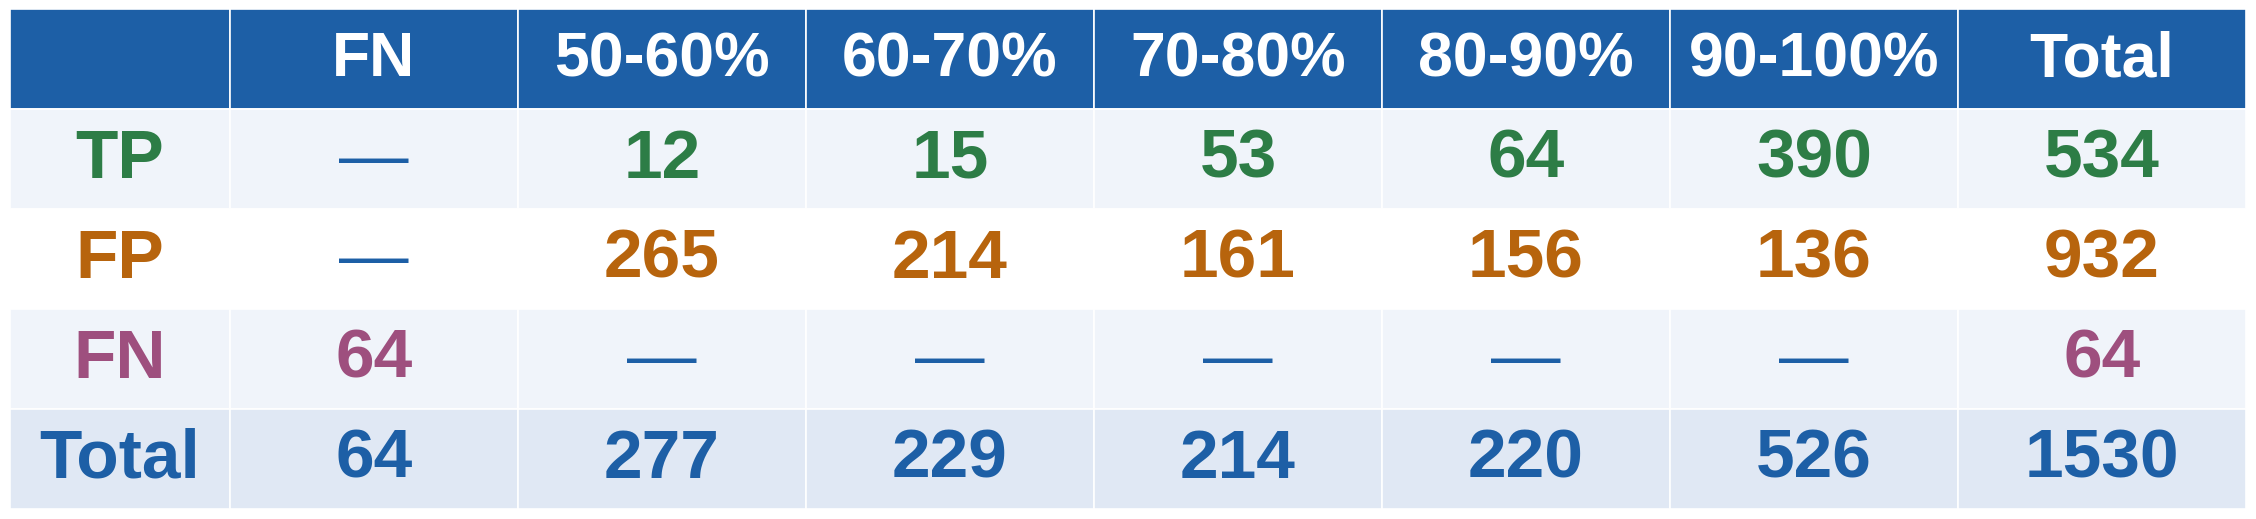

In [6]:
# ── Tag TP/FP and create confidence bins ──────────────────────────────────────
# Note: dl and johnson already loaded and reprojected from Stats cell above
dl['outcome'] = dl['match'].map({True: 'TP', False: 'FP'})

# 1 = 50-60% | 2 = 60-70% | 3 = 70-80% | 4 = 80-90% | 5 = 90-100%
bins_conf = [0.50, 0.60, 0.70, 0.80, 0.90, 1.001]
dl['conf_bin'] = pd.cut(dl['confidence'], bins=bins_conf, labels=[1, 2, 3, 4, 5], right=False).astype('Int64')

# ── Cross tabulate conf_bin vs TP/FP ─────────────────────────────────────────
result = pd.crosstab(dl['conf_bin'], dl['outcome'])
for col in ['TP', 'FP']:
    if col not in result.columns:
        result[col] = 0
result = result[['TP', 'FP']]
result['Total'] = result.sum(axis=1)

# ── Add FN row as bin 0 ───────────────────────────────────────────────────────
fn_row = pd.DataFrame({'TP': [0], 'FP': [0], 'Total': [FN]}, index=pd.Index([0], name='conf_bin'))
result = pd.concat([fn_row, result]).sort_index()
result.loc['Total'] = result.sum()

print("conf_bin key:")
print("  0 = FN  |  1 = 50-60%  |  2 = 60-70%  |  3 = 70-80%  |  4 = 80-90%  |  5 = 90-100%")
print()
print(result.to_string())

# ── Build data for figure ─────────────────────────────────────────────────────
# Pull values directly from result table
bins_list = [0, 1, 2, 3, 4, 5]
tp_vals   = [int(result.loc[b, 'TP']) if b in result.index else 0 for b in bins_list]
fp_vals   = [int(result.loc[b, 'FP']) if b in result.index else 0 for b in bins_list]
fn_vals   = [int(FN), 0, 0, 0, 0, 0]
tot_vals  = [int(result.loc[b, 'Total']) if b in result.index else 0 for b in bins_list]
total_row = [int(result.loc['Total', 'TP']), int(result.loc['Total', 'FP']),
             int(FN), int(result.loc['Total', 'Total'])]

col_labels = ['', 'FN', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', 'Total']

data = [
    {'label': 'TP',    'color': col_tp,      'values': [tp_vals[0]] + tp_vals[1:] + [total_row[0]]},
    {'label': 'FP',    'color': col_fp,      'values': [fp_vals[0]] + fp_vals[1:] + [total_row[1]]},
    {'label': 'FN',    'color': col_fn,      'values': fn_vals + [total_row[2]]},
    {'label': 'Total', 'color': POSTER_BLUE, 'values': tot_vals + [total_row[3]]},
]

# ── Draw figure ───────────────────────────────────────────────────────────────
n_rows      = len(data)
n_cols      = len(col_labels)
row_height  = 1
header_h    = 1
col_w_label = 2.2
col_w_data  = 2.88
total_w     = col_w_label + (n_cols - 1) * col_w_data
total_h     = header_h + n_rows * row_height

fig, ax = plt.subplots(figsize=(total_w, total_h))
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.axis('off')

col_x      = [0] + [col_w_label + i * col_w_data for i in range(n_cols - 1)]
col_widths = [col_w_label] + [col_w_data] * (n_cols - 1)

# Header
for c, (label, x, w) in enumerate(zip(col_labels, col_x, col_widths)):
    bg = POSTER_BLUE if c > 0 else '#1d5fa6'
    rect = mpatches.Rectangle((x, total_h - header_h), w, header_h,
                               facecolor=bg, edgecolor='white', linewidth=1.2)
    ax.add_patch(rect)
    if label:
        ax.text(x + w/2, total_h - header_h/2, label,
                ha='center', va='center', fontsize=45,
                fontfamily=FONT, fontweight='bold', color='white')

# Data rows
for r, row in enumerate(data):
    y        = total_h - header_h - (r + 1) * row_height
    is_total = row['label'] == 'Total'
    for c, (x, w) in enumerate(zip(col_x, col_widths)):
        bg = '#F0F4FA' if r % 2 == 0 else 'white'
        if is_total:
            bg = '#E0E8F4'
        rect = mpatches.Rectangle((x, y), w, row_height,
                                   facecolor=bg, edgecolor='white', linewidth=1.2)
        ax.add_patch(rect)
    ax.text(col_x[0] + col_widths[0]/2, y + row_height/2, row['label'],
            ha='center', va='center', fontsize=50,
            fontfamily=FONT, fontweight='bold', color=row['color'])
    for c, val in enumerate(row['values']):
        xi      = col_x[c + 1]
        wi      = col_widths[c + 1]
        display = str(val) if val > 0 else '—'
        fw      = 'bold' if (val > 0 or is_total) else 'normal'
        color   = row['color'] if val > 0 else POSTER_BLUE
        ax.text(xi + wi/2, y + row_height/2, display,
                ha='center', va='center', fontsize=50,
                fontfamily=FONT, fontweight=fw, color=color)

plt.tight_layout(pad=0)
out = f'{OUT_DIR}/fig3_confusion_matrix.png'
plt.savefig(out, dpi=600, bbox_inches='tight', facecolor='white')
print(f'Saved to {out}')
plt.show()

### Figure 4: Detections by Confidence Score

Saved to /uufs/chpc.utah.edu/common/home/u0972368/FFSL_HRWUI/data/outputs/fig4_confidence_linechart.png


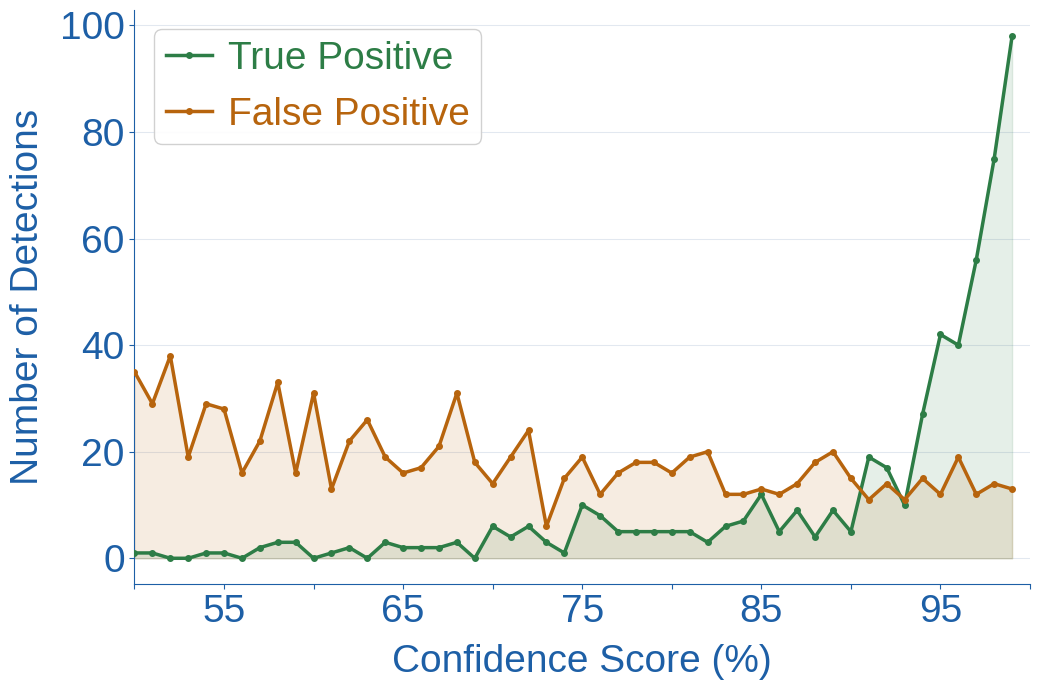

In [ ]:
# ── 1% confidence bins ────────────────────────────────────────────────────────
# Note: dl already loaded, reprojected, and match field set from Stats cell above
bins      = np.arange(0.50, 1.01, 0.01)
labels    = [f"{int(round(b*100))}" for b in bins[:-1]]
bin_centers = [int(round(b*100)) for b in bins[:-1]]

dl['bin'] = pd.cut(dl['confidence'], bins=bins, labels=labels, right=False)

tp_counts = dl[dl['match']].groupby('bin', observed=True).size().reindex(labels, fill_value=0)
fp_counts = dl[~dl['match']].groupby('bin', observed=True).size().reindex(labels, fill_value=0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 7))

ax.plot(bin_centers, tp_counts.values, color=col_tp, linewidth=2.5,
        marker='o', markersize=4, label='True Positive', zorder=3)
ax.plot(bin_centers, fp_counts.values, color=col_fp, linewidth=2.5,
        marker='o', markersize=4, label='False Positive', zorder=3)

ax.fill_between(bin_centers, tp_counts.values, alpha=0.12, color=col_tp)
ax.fill_between(bin_centers, fp_counts.values, alpha=0.12, color=col_fp)

xtick_positions = list(range(50, 101, 5))
xtick_labels    = [str(x) if x % 10 == 5 else '' for x in xtick_positions]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, fontsize=28, fontfamily=FONT)
ax.set_xlim(50, 100)

ax.set_xlabel('Confidence Score (%)', fontsize=28, labelpad=10, fontfamily=FONT, color=POSTER_BLUE)
ax.set_ylabel('Number of Detections', fontsize=28, labelpad=10, fontfamily=FONT, color=POSTER_BLUE)

ax.tick_params(axis='both', labelsize=28, colors=POSTER_BLUE)
for label in ax.get_yticklabels():
    label.set_fontfamily(FONT)
    label.set_color(POSTER_BLUE)
for label in ax.get_xticklabels():
    label.set_color(POSTER_BLUE)

ax.spines['left'].set_color(POSTER_BLUE)
ax.spines['bottom'].set_color(POSTER_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#E2E8F0', linewidth=0.75)
ax.set_axisbelow(True)

ax.legend(fontsize=28, framealpha=0.9, prop={'family': FONT, 'size': 28},
          loc='upper left', labelcolor=[col_tp, col_fp],
          borderpad=0.3, handletextpad=0.4, handlelength=1.2)

plt.tight_layout()
out = f'{OUT_DIR}/fig4_confidence_linechart.png'
plt.savefig(out, dpi=600, bbox_inches='tight')
print(f'Saved to {out}')
plt.show()

### Figure 5: Detection Outcome Legend

Saved to /uufs/chpc.utah.edu/common/home/u0972368/FFSL_HRWUI/data/outputs/fig5_legend_2d_3bin_rotFalse_oneTrue.png


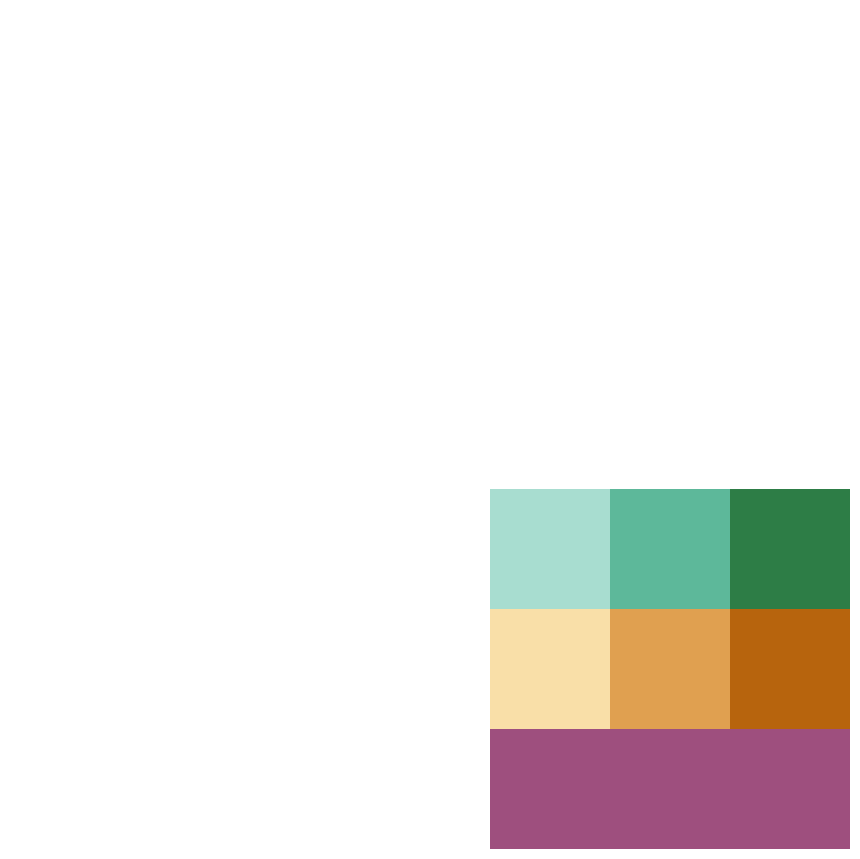

In [13]:
# ── TOGGLES ───────────────────────────────────────────────────────────────────
ROTATE   = False   # True = rotate 90° clockwise
ONE_BOX  = True   # False = gradient (light→dark) | True = 3x3 grid, bottom row all pink

# ── COLORS ────────────────────────────────────────────────────────────────────
tp_colors = ['#A8DDD0', '#5DB89A', '#2D7D46']
fp_colors = ['#F9DFA8', '#E0A050', '#B7640D']
fn_color  = '#9E4F7E'

N_BINS  = 3
sq      = 1.0
n_rows  = 3
pad     = sq * 4

# ── Row colors based on toggle ────────────────────────────────────────────────
row_colors = [
    tp_colors,                    # TP: light → dark green
    fp_colors,                    # FP: light → dark orange
    [fn_color] * 3                # FN: three identical pink squares
] if ONE_BOX else [
    tp_colors,
    fp_colors,
    [fn_color]                    # FN: single pink (gradient mode)
]

# When ONE_BOX=False, FN row has only 1 color but we still draw 3 squares
# so pad it out
row_colors_draw = []
for row in row_colors:
    if len(row) < N_BINS:
        row = row + ['white'] * (N_BINS - len(row))
    row_colors_draw.append(row)

# ── Canvas ────────────────────────────────────────────────────────────────────
if ROTATE:
    total_w = n_rows * sq + pad
    total_h = N_BINS * sq + pad
else:
    total_w = N_BINS * sq + pad
    total_h = n_rows * sq + pad

fig, ax = plt.subplots(figsize=(total_w * 1.2, total_h * 1.2))
ax.set_xlim(0, total_w)
ax.set_ylim(0, total_h)
ax.set_aspect('equal')
ax.axis('off')

for r, row in enumerate(row_colors_draw):
    for c in range(N_BINS):
        color = row[c]

        if ROTATE:
            x = pad + r * sq
            y = (N_BINS - 1 - c) * sq
        else:
            x = pad + c * sq
            y = (n_rows - 1 - r) * sq

        rect = mpatches.Rectangle(
            (x, y), sq, sq,
            facecolor=color,
            edgecolor='none',
            linewidth=0
        )
        ax.add_patch(rect)

plt.tight_layout(pad=0)
out = f'{OUT_DIR}/fig5_legend_2d_3bin_rot{ROTATE}_one{ONE_BOX}.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved to {out}')
plt.show()

Test For best location and style

Saved to /uufs/chpc.utah.edu/common/home/u0972368/FFSL_HRWUI/data/outputs/fig5_legend_2d_3bin_rot0_oneTrue_fnright.png


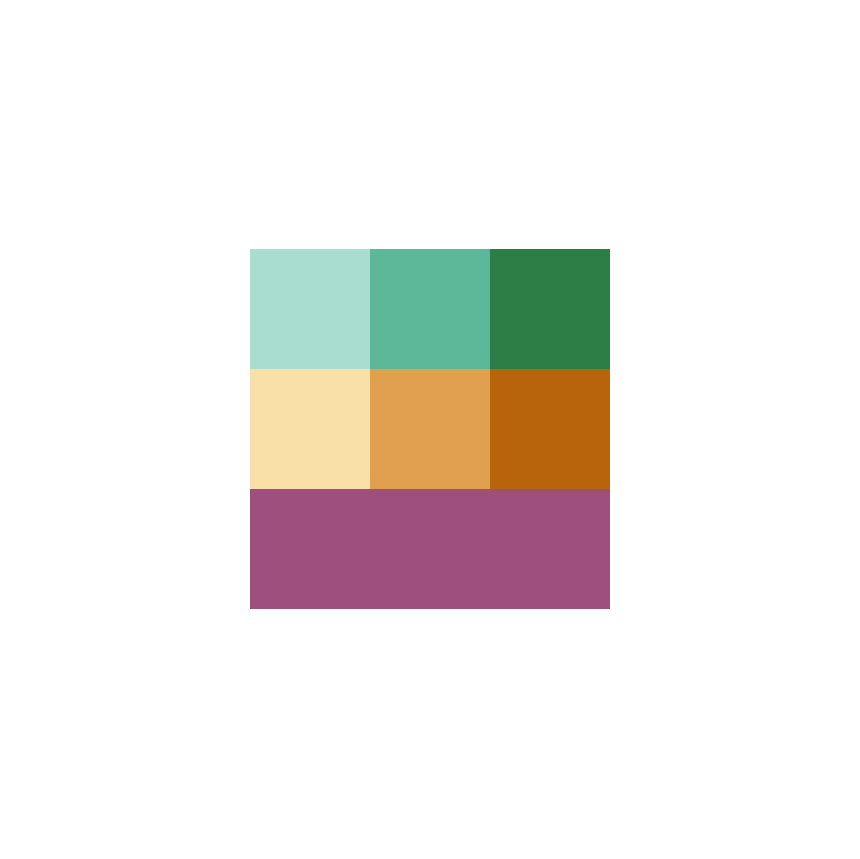

In [22]:
# ── TOGGLES ───────────────────────────────────────────────────────────────────
ROTATE   = 0       # 0, 45, 135, 225, or 315 degrees
ONE_BOX  = True   # False = gradient | True = 3x3 full grid, bottom row all pink
FN_SIDE  = 'right'  # 'left' or 'right' — only applies when ONE_BOX = False

# ── COLORS ────────────────────────────────────────────────────────────────────
tp_colors = ['#A8DDD0', '#5DB89A', '#2D7D46']
fp_colors = ['#F9DFA8', '#E0A050', '#B7640D']
fn_color  = '#9E4F7E'

N_BINS = 3
sq     = 1.0
n_rows = 3
pad    = sq * 4

# ── Row colors ────────────────────────────────────────────────────────────────
if ONE_BOX:
    # 3x3 grid — bottom row all pink
    row_colors_raw = [tp_colors, fp_colors, [fn_color] * 3]
else:
    # Gradient — single pink square on left or right
    if FN_SIDE == 'left':
        fn_row = [fn_color, 'white', 'white']
    else:
        fn_row = ['white', 'white', fn_color]
    row_colors_raw = [tp_colors, fp_colors, fn_row]

# ── Build patch centers (unrotated, centered at origin) ───────────────────────
patches = []
for r, row in enumerate(row_colors_raw):
    for c in range(N_BINS):
        cx = (c - (N_BINS - 1) / 2) * sq
        cy = ((n_rows - 1 - r) - (n_rows - 1) / 2) * sq
        patches.append((cx, cy, row[c]))

# ── Rotate patch centers ──────────────────────────────────────────────────────
angle_rad = np.radians(ROTATE)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

rotated = []
for (cx, cy, color) in patches:
    rx = cx * cos_a - cy * sin_a
    ry = cx * sin_a + cy * cos_a
    rotated.append((rx, ry, color))

# ── Canvas ────────────────────────────────────────────────────────────────────
xs = [rx for rx, ry, _ in rotated]
ys = [ry for rx, ry, _ in rotated]
block_half_w = max(abs(min(xs)), abs(max(xs))) + sq / 2
block_half_h = max(abs(min(ys)), abs(max(ys))) + sq / 2

canvas_w = block_half_w * 2 + pad
canvas_h = block_half_h * 2 + pad

fig, ax = plt.subplots(figsize=(canvas_w * 1.2, canvas_h * 1.2))
ax.set_xlim(-canvas_w / 2, canvas_w / 2)
ax.set_ylim(-canvas_h / 2, canvas_h / 2)
ax.set_aspect('equal')
ax.axis('off')

# ── Draw patches ─────────────────────────────────────────────────────────────
for (rx, ry, color) in rotated:
    if color == 'white':
        continue   # skip white — just leave canvas background
    if ROTATE in (0, 90, 180, 270):
        rect = mpatches.Rectangle(
            (rx - sq / 2, ry - sq / 2), sq, sq,
            facecolor=color, edgecolor='none', linewidth=0
        )
        ax.add_patch(rect)
    else:
        corners = np.array([
            [-sq/2, -sq/2], [ sq/2, -sq/2],
            [ sq/2,  sq/2], [-sq/2,  sq/2],
        ])
        rot_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
        rotated_corners = corners @ rot_matrix.T
        rotated_corners[:, 0] += rx
        rotated_corners[:, 1] += ry
        poly = mpatches.Polygon(
            rotated_corners, closed=True,
            facecolor=color, edgecolor='none', linewidth=0
        )
        ax.add_patch(poly)

plt.tight_layout(pad=0)
out = f'{OUT_DIR}/fig5_legend_2d_3bin_rot{ROTATE}_one{ONE_BOX}_fn{FN_SIDE}.png'
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved to {out}')
plt.show()